In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

for _path in (Path.cwd(), *Path.cwd().parents):
    if (_path / "pyproject.toml").is_file():
        _root = str(_path)
        if _root not in sys.path:
            sys.path.insert(0, _root)
        break
else:
    raise RuntimeError("Could not find project root (pyproject.toml)")

import numpy as np
import torch
from core.weak_sm_cell import WeakSMCell
from core.paths import DATA_DIR
from analysis.paths import CKPT_DIR, PLOTS_DIR
from models.utils import build_rae
from core.training import TrainMode, train_rae_epochs
from analysis.cell_evolution_analysis import (
    select_active_cells,
    fit_gaussian_sums,
    mean_r2_by_n_gaussians,
    mean_r2_by_n_and_maxfev,
    print_gaussian_fit_summary,
    select_cells_sensitive_to_n,
)
from analysis.cell_evolution_plots import (
    plot_ratemap_evolution,
    plot_gaussian_fits,
    plot_mean_r2_vs_n_gaussians,
    plot_mean_r2_by_n_and_maxfev,
    plot_wall_time_by_n_and_maxfev,
    plot_cells_sensitive_to_n,
)


# Load trajectory and arena map


In [2]:
ARENA_NAME = '100x100_square'
explore_speed = 'fast'  # 'fast', 'med', 'slow'
boundary_avoidance = False  # True, False

load_dir = DATA_DIR / ARENA_NAME
traj_name = f'traj_{explore_speed}' if not boundary_avoidance else f'traj_{explore_speed}_ba'
arena_map = np.load(load_dir / 'arena_map.npz')['arena_map']
traj_coord = np.load(load_dir / f'{traj_name}.npz')['coord']


# Initialize WeakSMCell and RAE


In [3]:
N_CELLS = 200
WSM_SIGMA = 12
WSM_SSIGMA = 0
WSM_MAGNITUDE = 4
N_HIDDEN = 1024
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')

wsm = WeakSMCell(
    arena_map=arena_map,
    n_cells=N_CELLS,
    sigma=WSM_SIGMA,
    ssigma=WSM_SSIGMA,
    magnitude=WSM_MAGNITUDE,
    seed=42,
)

rae = build_rae(N_CELLS, N_HIDDEN, DEVICE)


# Training hyperparameters and helpers

Set `TRAIN_MODE` to `"default"` (batch 512) or `"indiv_traj"` (batch 8 per trajectory).


In [ ]:
CKPT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_MODE: TrainMode = "indiv_traj"# "default"  # "default" | "indiv_traj"

MASK_RATE = 0.50
LEARNING_RATE = 0.005
N_EPOCHS = 5
STEP_SIZE = 20 * 15 # 20 is 1s (DT = 0.05s)
LAMBDA_MSE = 1
LAMBDA_FR = 100


# Train RAE and log rate maps at end of each epoch


In [5]:
epoch_ratemaps = train_rae_epochs(
    rae,
    traj_coord,
    wsm,
    arena_map,
    DEVICE,
    mask_rate=MASK_RATE,
    learning_rate=LEARNING_RATE,
    n_epochs=N_EPOCHS,
    step_size=STEP_SIZE,
    lambda_mse=LAMBDA_MSE,
    lambda_fr=LAMBDA_FR,
    train_mode=TRAIN_MODE,
    ckpt_dir=CKPT_DIR,
)


Rate map:   0%|          | 0/17 [00:00<?, ?it/s]

Training:   0%|          | 0/5 [00:00<?, ?it/s]

  epoch 0 ratemaps: shape=(1024, 110, 110), mean peak activation=0.0450
  epoch 1 ratemaps: shape=(1024, 110, 110), mean peak activation=0.0343
  epoch 2 ratemaps: shape=(1024, 110, 110), mean peak activation=0.0287
  epoch 3 ratemaps: shape=(1024, 110, 110), mean peak activation=0.0261
  epoch 4 ratemaps: shape=(1024, 110, 110), mean peak activation=0.0261
Done. Logged 6 epoch ratemaps.


# Evolution plot: one row per cell, one column per epoch


In [6]:
MAX_ACTIVATION_THRESHOLD = 0.2
MAX_CELLS_TO_PLOT = 50
IM_WIDTH = 2

final_rm = epoch_ratemaps[-1]
cell_indices, peak = select_active_cells(
    final_rm,
    threshold=MAX_ACTIVATION_THRESHOLD,
    max_cells=MAX_CELLS_TO_PLOT,
)


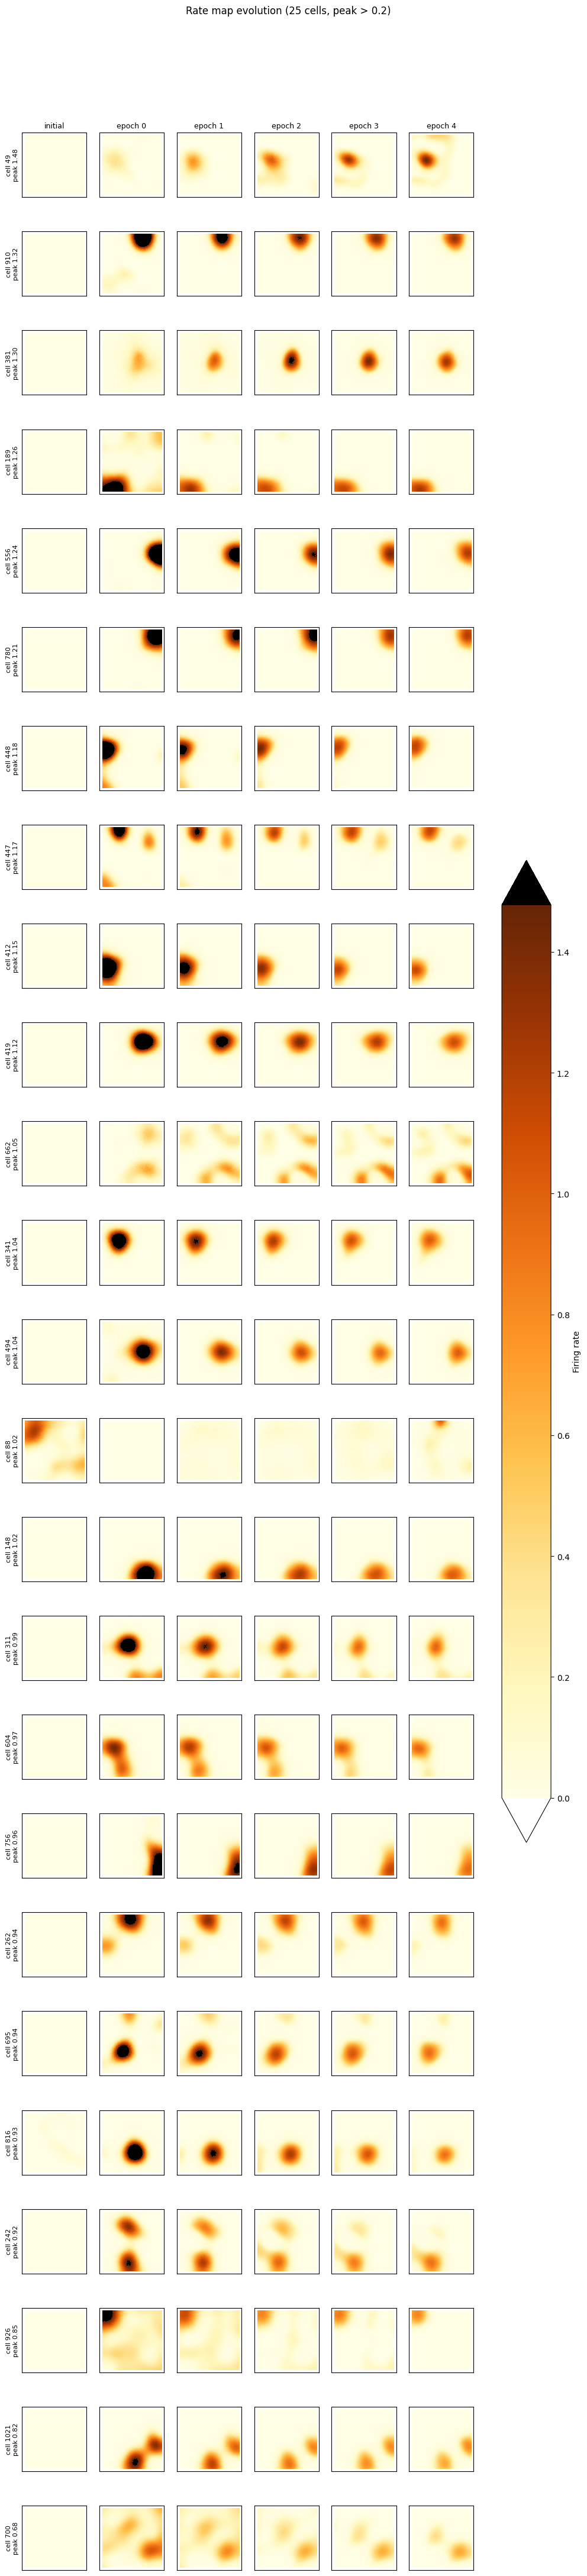

In [7]:
plot_ratemap_evolution(
    epoch_ratemaps,
    cell_indices,
    peak,
    threshold=MAX_ACTIVATION_THRESHOLD,
    im_width=IM_WIDTH,
    output_dir=PLOTS_DIR,
)


# Gaussian-sum fits


In [8]:
N_GAUSSIANS = 2

gaussian_fits = fit_gaussian_sums(final_rm, cell_indices, n_gaussians=N_GAUSSIANS)
print_gaussian_fit_summary(gaussian_fits, N_GAUSSIANS)


Gaussian fits (N=2, cpu):   0%|          | 0/25 [00:00<?, ?it/s]

Gaussian sum fits (N=2, final epoch):
  cell       R²          AIC
    49    0.914     -53603.1
       g1: amp=1.421 μ=(28.9,47.2) σ=(9.9,8.6)
       g2: amp=0.200 μ=(46.5,0.0) σ=(22.9,59.1)
   910    0.996     -84033.0
       g1: amp=1.308 μ=(79.3,13.0) σ=(9.9,13.1)
       g2: amp=0.556 μ=(63.5,10.3) σ=(6.8,10.3)
   381    0.995     -82125.5
       g1: amp=1.262 μ=(63.3,51.8) σ=(10.4,10.4)
       g2: amp=0.359 μ=(64.0,64.6) σ=(9.4,6.1)
   189    0.996     -86360.9
       g1: amp=0.595 μ=(31.3,102.3) σ=(10.1,11.0)
       g2: amp=1.139 μ=(10.8,99.3) σ=(14.9,10.8)
   556    0.997     -87867.4
       g1: amp=1.035 μ=(97.0,35.7) σ=(13.0,10.2)
       g2: amp=0.758 μ=(101.9,52.1) σ=(12.3,8.8)
   780    0.997     -90023.0
       g1: amp=0.445 μ=(100.5,28.2) σ=(11.2,8.3)
       g2: amp=1.178 μ=(97.9,10.6) σ=(12.6,12.3)
   448    0.994     -82836.4
       g1: amp=1.131 μ=(12.7,30.9) σ=(12.2,9.8)
       g2: amp=0.683 μ=(7.5,47.4) σ=(10.2,7.8)
   447    0.988     -76278.0
       g1: amp=1.253 μ=(

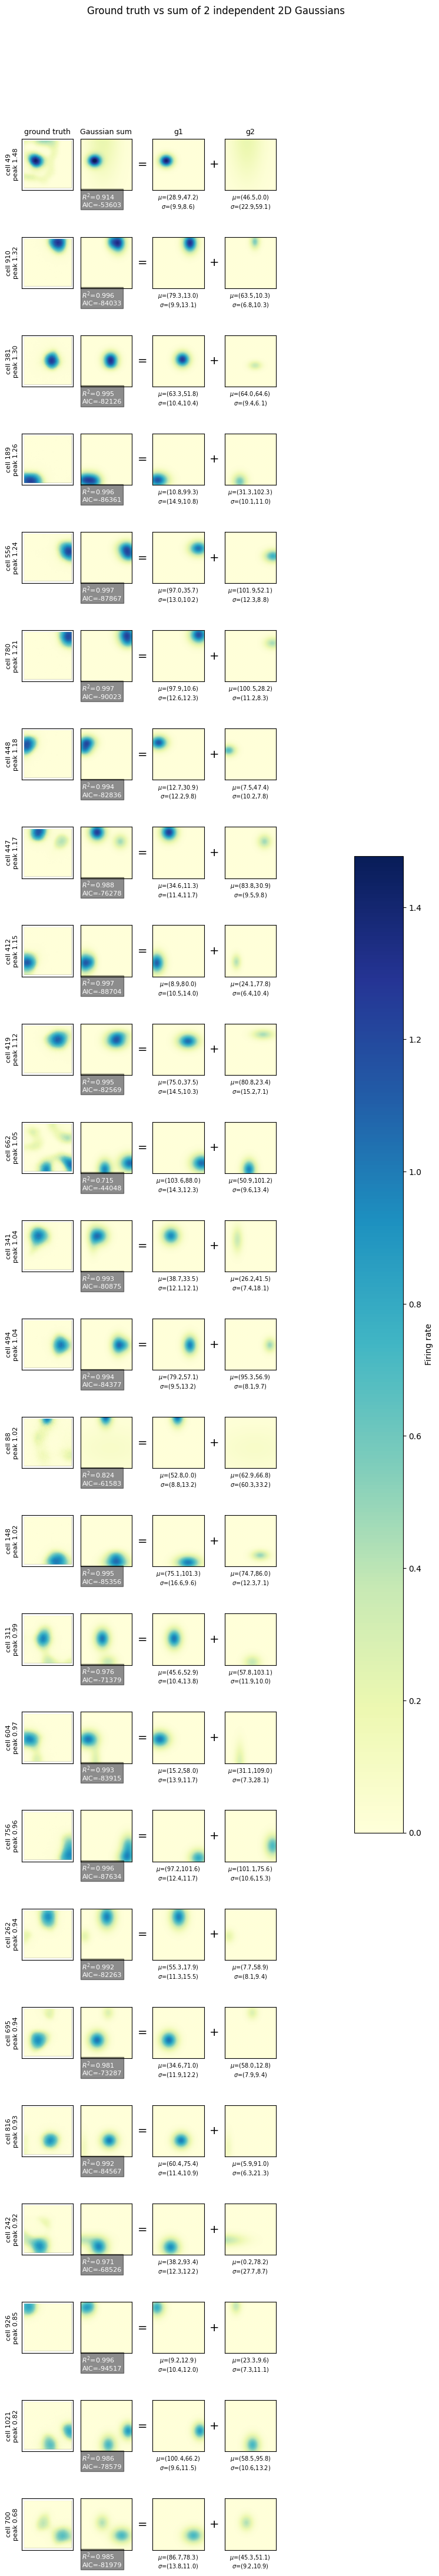

In [9]:
plot_gaussian_fits(
    final_rm,
    gaussian_fits,
    n_gaussians=N_GAUSSIANS,
    im_width=IM_WIDTH,
    output_dir=PLOTS_DIR,
)


# Mean R² vs number of Gaussians


In [10]:
MAXFEV_VALUES = np.linspace(1,100,10)#np.sort(np.r_[np.logspace(2, 4, 5), 2 * np.logspace(2, 4, 5)]).astype(int)
N_VALUES = [1, 2, 3]

r2_grid = mean_r2_by_n_and_maxfev(
    final_rm,
    cell_indices,
    n_gaussians_values=N_VALUES,
    maxfev_values=MAXFEV_VALUES,
)


R² grid vs N and maxfev:   0%|          | 0/3 [00:00<?, ?it/s]

maxfev (N=1):   0%|          | 0/10 [00:00<?, ?it/s]

maxfev (N=2):   0%|          | 0/10 [00:00<?, ?it/s]

maxfev (N=3):   0%|          | 0/10 [00:00<?, ?it/s]

Gaussian grid total wall time: 324.7 s


In [11]:
plot_mean_r2_by_n_and_maxfev(r2_grid, n_cells=len(cell_indices),log_scale=False)
plot_wall_time_by_n_and_maxfev(r2_grid, n_cells=len(cell_indices),log_scale=False)

r2_grid


{'n_values': array([1, 2, 3]),
 'maxfev_values': array([  1,  12,  23,  34,  45,  56,  67,  78,  89, 100]),
 'mean_r2': array([[       nan, 0.95197685, 0.9142982 , 0.89182423, 0.89182423,
         0.89182423, 0.89182423, 0.89182423, 0.89182423, 0.89182423],
        [       nan, 0.9841536 , 0.96470778, 0.9736478 , 0.97650514,
         0.97650514, 0.9703987 , 0.9703987 , 0.9703987 , 0.9703987 ],
        [       nan,        nan, 0.96752059, 0.98361666, 0.97667762,
         0.98057367, 0.98248202, 0.98324505, 0.98391534, 0.98391534]]),
 'wall_time_s': array([[ 0.2116388 ,  1.52330279,  0.87453018,  0.49290808,  0.51065083,
          0.93298469,  1.40707597,  0.89254225,  0.50774255,  1.27030032],
        [ 0.09442742,  3.51218665,  5.5721279 ,  6.66528823,  6.99935965,
          7.34082906,  6.72533999,  7.02419293,  6.66551512,  8.19057893],
        [ 0.27179612,  9.54506053, 20.88999997, 25.50960401, 26.97521181,
         30.62987444, 33.60068672, 31.63480328, 35.08067467, 43.1262418 ]])

In [12]:
assert False


AssertionError: 

In [13]:
N_GAUSSIANS = 5
r2_by_n = mean_r2_by_n_gaussians(final_rm, cell_indices, n_gaussians_range=N_GAUSSIANS,device="cpu")
r2_by_n


Mean R² vs N Gaussians (cpu):   0%|          | 0/5 [00:00<?, ?it/s]

{'n_values': array([0, 1, 2, 3, 4]),
 'mean_r2': array([       nan, 0.89182423, 0.9703987 , 0.98391534, 0.99003952]),
 'gaussian_fits_by_n': {1: [{'components': [array([[4.14715617e-07, 5.24295434e-07, 6.57541467e-07, ...,
             6.10756170e-16, 3.27703926e-16, 1.74428245e-16],
            [6.73214115e-07, 8.51096686e-07, 1.06739698e-06, ...,
             9.91449703e-16, 5.31966726e-16, 2.83152000e-16],
            [1.08152040e-06, 1.36728926e-06, 1.71477630e-06, ...,
             1.59276678e-15, 8.54606067e-16, 4.54884498e-16],
            ...,
            [3.09345639e-10, 3.91083672e-10, 4.90474863e-10, ...,
             4.55576666e-19, 2.44441676e-19, 1.30109923e-19],
            [1.64841110e-10, 2.08396881e-10, 2.61359497e-10, ...,
             2.42763283e-19, 1.30255714e-19, 6.93317161e-20],
            [8.69292113e-11, 1.09898414e-10, 1.37828331e-10, ...,
             1.28021589e-19, 6.86905501e-20, 3.65621865e-20]], shape=(110, 110))],
    'component_params': [{'amplitude'

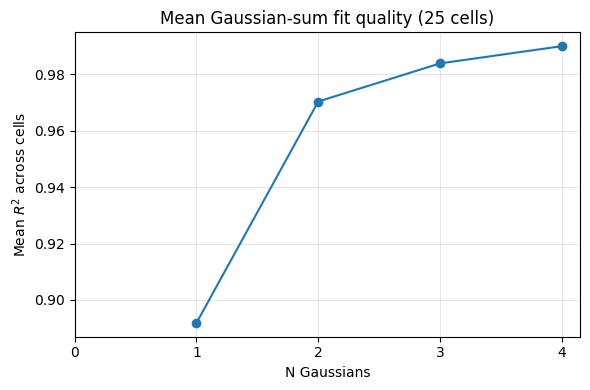

In [15]:
plot_mean_r2_vs_n_gaussians(
    r2_by_n, n_cells=len(cell_indices), output_dir=PLOTS_DIR
)


In [16]:
r2_by_n["gaussian_fits_by_n"][4][9]


{'components': [array([[8.37682708e-07, 1.21386789e-06, 1.74116651e-06, ...,
          1.19435877e-14, 5.82058679e-15, 2.80786190e-15],
         [1.07394826e-06, 1.55623519e-06, 2.23225659e-06, ...,
          1.53122359e-14, 7.46226344e-15, 3.59980977e-15],
         [1.36908665e-06, 1.98391385e-06, 2.84571690e-06, ...,
          1.95202867e-14, 9.51301443e-15, 4.58909587e-15],
         ...,
         [3.46349335e-09, 5.01887328e-09, 7.19904873e-09, ...,
          4.93821065e-17, 2.40658706e-17, 1.16094208e-17],
         [2.42438563e-09, 3.51312477e-09, 5.03921000e-09, ...,
          3.45666232e-17, 1.68456945e-17, 8.12639437e-18],
         [1.68745739e-09, 2.44525800e-09, 3.50746682e-09, ...,
          2.40595816e-17, 1.17251939e-17, 5.65625538e-18]], shape=(110, 110)),
  array([[1.01656205e-15, 1.47959842e-15, 2.13554654e-15, ...,
          6.02066881e-19, 3.56995788e-19, 2.09911710e-19],
         [1.78481526e-15, 2.59778517e-15, 3.74945734e-15, ...,
          1.05707089e-18, 6.2679059

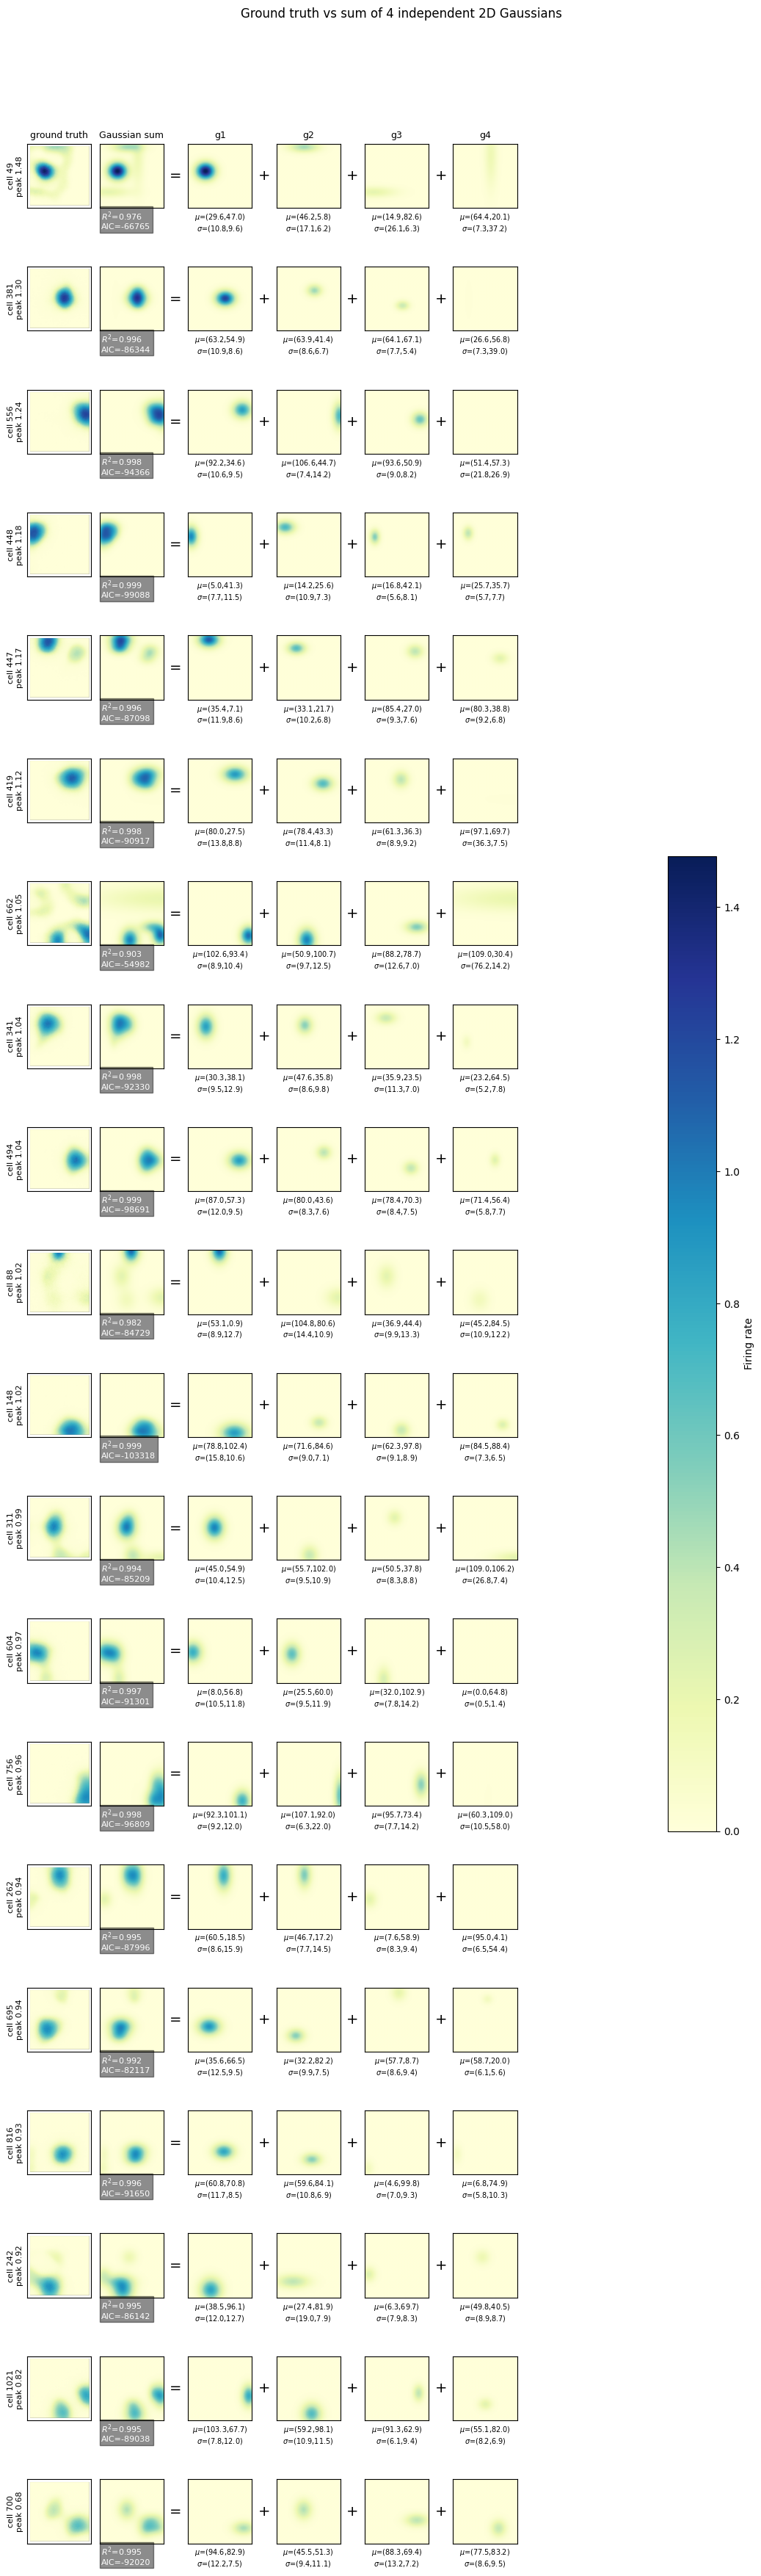

In [17]:
n_th = N_GAUSSIANS-1
plot_gaussian_fits(
    final_rm,
    r2_by_n["gaussian_fits_by_n"][n_th],
    n_gaussians=n_th,
    im_width=IM_WIDTH,
    output_dir=PLOTS_DIR,
)


2 cells with SEM(R²) > 0.1


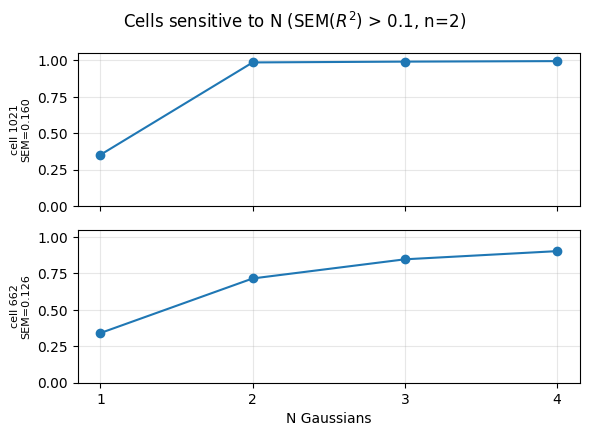

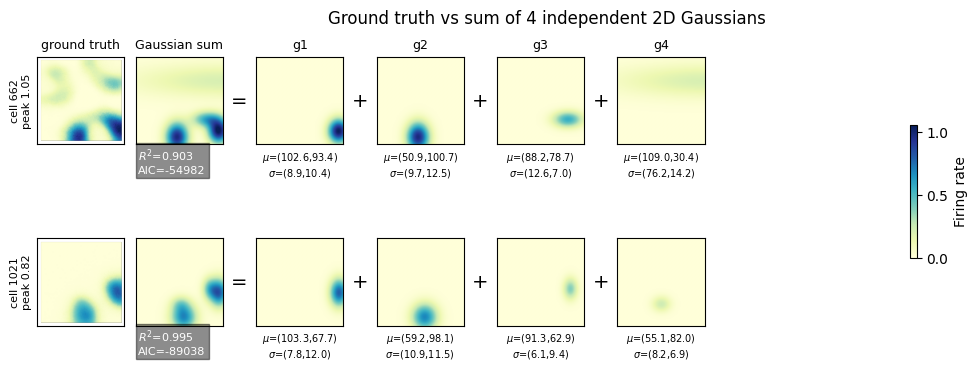

In [18]:
SEM_THRESHOLD = 0.1

sensitive_cells, sem_by_cell, r2_by_cell, n_values = select_cells_sensitive_to_n(
    r2_by_n,
    sem_threshold=SEM_THRESHOLD,
)
print(f"{len(sensitive_cells)} cells with SEM(R²) > {SEM_THRESHOLD}")

plot_cells_sensitive_to_n(
    r2_by_n,
    sem_threshold=SEM_THRESHOLD,
    output_dir=PLOTS_DIR,
)

sensitive_set = set(sensitive_cells)
sensitive_fits = [
    fit for fit in r2_by_n["gaussian_fits_by_n"][n_th]
    if fit["cell_idx"] in sensitive_set
]
plot_gaussian_fits(
    final_rm,
    sensitive_fits,
    n_gaussians=n_th,
    im_width=IM_WIDTH,
    output_dir=PLOTS_DIR,
    save_name=f"gaussian_fits_n{n_th}_sensitive_to_n.pdf",
)


Gaussian fits (N=7, cpu):   0%|          | 0/2 [00:00<?, ?it/s]

Gaussian sum fits (N=7, final epoch):
  cell       R²          AIC
  1021    0.994     -86476.1
       g1: amp=0.721 μ=(58.6,95.7) σ=(10.7,13.2)
       g2: amp=0.477 μ=(92.3,62.6) σ=(6.4,8.7)
       g3: amp=0.623 μ=(103.4,74.7) σ=(7.9,7.9)
       g4: amp=0.506 μ=(104.9,59.0) σ=(7.4,7.9)
       g5: amp=0.004 μ=(16.3,107.3) σ=(7.9,44.1)
       g6: amp=0.001 μ=(80.3,9.2) σ=(74.3,15.4)
       g7: amp=0.011 μ=(107.4,41.1) σ=(30.6,9.6)
   662    0.985     -73862.5
       g1: amp=0.976 μ=(50.9,100.7) σ=(9.7,12.4)
       g2: amp=0.234 μ=(26.5,50.1) σ=(12.3,8.4)
       g3: amp=0.209 μ=(68.3,11.1) σ=(9.1,10.7)
       g4: amp=0.546 μ=(88.0,78.6) σ=(12.6,7.1)
       g5: amp=0.256 μ=(24.7,22.7) σ=(9.4,7.9)
       g6: amp=1.046 μ=(102.6,93.3) σ=(8.8,10.5)
       g7: amp=0.445 μ=(95.1,33.3) σ=(12.6,7.8)


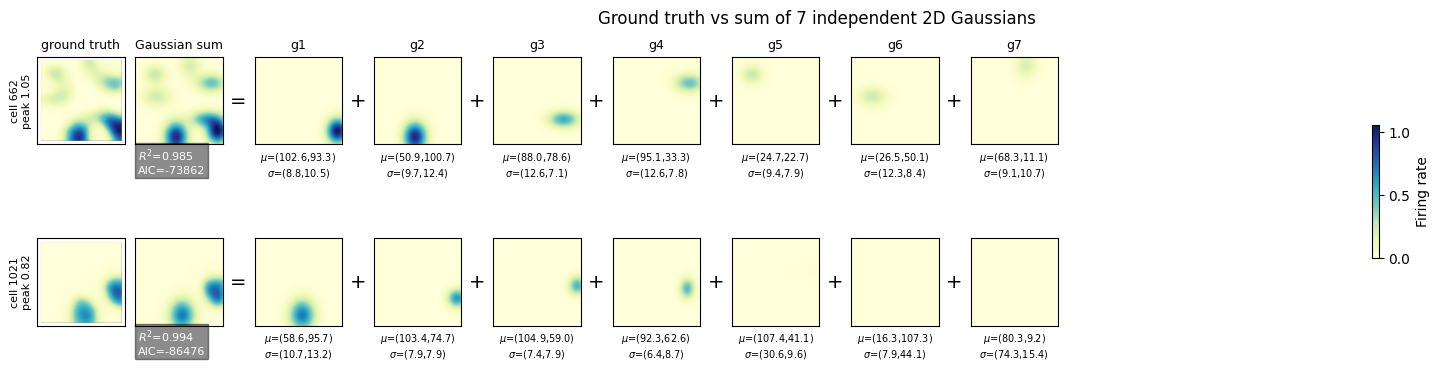

: 

In [ ]:
# Fit N=7 only for cells already selected as sensitive to N (no 1..7 sweep)
N_FURTHER_GAUSSIANS = 7

further_fits = fit_gaussian_sums(
    final_rm,
    sensitive_cells,
    n_gaussians=N_FURTHER_GAUSSIANS,
    device="cpu",
)
print_gaussian_fit_summary(further_fits, N_FURTHER_GAUSSIANS)

plot_gaussian_fits(
    final_rm,
    further_fits,
    n_gaussians=N_FURTHER_GAUSSIANS,
    im_width=IM_WIDTH,
    output_dir=PLOTS_DIR,
    save_name=f"gaussian_fits_n{N_FURTHER_GAUSSIANS}_sensitive_to_n.pdf",
)
